# CRSP, Compustat, CCM, and FF3
Bozhi Fu; 20 May 2026

This is a replicating code for freshmans using CRSP and Compustat refers to tidyfinance and wrds instrcution.

References:

[1] https://www.tidy-finance.org/python/wrds-crsp-and-compustat.html#downloading-and-preparing-crsp

[2] https://www.crsp.org/wp-content/uploads/guides/CRSP_US_Stock_&_Indexes_Database_Data_Descriptions_Guide.pdf

[3] https://www.crsp.org/wp-content/uploads/guides/CRSP_US_Stock_&_Indexes_Database_Guide_Flat_File_Format_2.0.pdf

[4] https://wrds-www.wharton.upenn.edu/pages/wrds-research/applications/python-replications/fama-french-factors-python/

# Section 1 Accessing WRDS

In [552]:
# Accessing WRDS
# Create .pgpass file for remaining logging in

import wrds

db = wrds.Connection()

Enter your WRDS username [fubozhi]: david112
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


In [4]:
# print accessible libraries

print(db.list_libraries())

['aha_sample', 'ahasamp', 'audit', 'audit_audit_comp', 'audit_common', 'audit_corp_legal', 'auditsmp', 'auditsmp_all', 'bank', 'bank_all', 'bank_premium_samp', 'banksamp', 'block', 'block_all', 'boardex_trial', 'boardsmp', 'bvd_amadeus_trial', 'bvd_bvdbankf_trial', 'bvd_orbis_trial', 'bvdsamp', 'calcbench_trial', 'calcbnch', 'candid_samp', 'cboe', 'cboe_all', 'cboe_sample', 'cboesamp', 'cddsamp', 'ciq', 'ciq_common', 'ciq_transcripts', 'ciqsamp', 'ciqsamp_capstrct', 'ciqsamp_common', 'ciqsamp_keydev', 'ciqsamp_pplintel', 'ciqsamp_ratings', 'ciqsamp_transactions', 'ciqsamp_transcripts', 'cisdmsmp', 'columnar', 'comp', 'comp_bank_daily', 'comp_execucomp', 'comp_global_daily', 'comp_na_daily_all', 'comp_segments_hist_daily', 'compsamp', 'compsamp_all', 'compsamp_computext', 'compsamp_snapshot', 'compseg', 'contrib', 'contrib_as_filed_financials', 'contrib_bond_firm_link', 'contrib_ceo_turnover', 'contrib_char_returns', 'contrib_corp_fed_litigation', 'contrib_corporate_culture', 'contrib_g

In [21]:
# commonly used database
# 'crsp'
# 

# Section 2 Preparing Compustat Data

* Compustat North America is a database of U.S. and Canadian fundamental and market information on active and inactive publicly held companies. It provides more than 300 annual and 100 quarterly Income Statements, Balance Sheets, Statement of Cash Flows, and supplemental data items. For most companies, annual history is available back to 1950, and quarterly history back to 1962, with monthly market history back to 1962.
* Compustat North America files also contain information on aggregates, industry segments, banks, market prices, dividends, and earnings.
* Draws data from companies’ SEC filings (10-K, 10-Q)

In [305]:
###################
# Compustat Block #
###################

# Load annual Compustat fundamentals (North America) needed to construct book equity, operating profitability and investment ratio

# book equity = stockholders’ equity + deferred taxes - preferred stock

# build stockholders’ equity
# 1. seq (Stockholders Equity - Parent)
# 2. ceq (Common/Ordinary Equity - Total) + pstk (Preferred/Preference Stock (Capital) - Total)
# 3. at (Assets - Total) - lt (Liabilities - Total)

# build deferred tax
# 1. txditc (Deferred Taxes and Investment Tax Credit)
# 2. txdb (Deferred Taxes (Balance Sheet)) + itcb (Investment Tax Credit (Balance Sheet))

# build preferred stock
# 1. pstkrv (Preferred Stock - Redemption Value)
# 2. pstkl (Preferred Stock - Liquidating Value)
# 3. pstk (Preferred/Preference Stock (Capital) - Total)

# operating profitability = (sale - cogs - sg&a - interest expense) / book equity

# sale (Sales/Turnover (Net))
# cogs (Cost of Goods Sold)
# xsga (Selling, General and Administrative Expense)
# xint (Interest and Related Expense - Total)

# investment ratio = total assets / total assets_lagged - 1

comp = db.raw_sql("""
                    select gvkey, datadate, seq, ceq, pstk, at, lt, 
                    txditc, txdb, itcb, pstkrv, pstkl,
                    sale, cogs, xsga, xint
                    from comp.funda
                    where indfmt = 'INDL'          -- industrial format
                    and datafmt = 'STD'          -- standard data format
                    and popsrc = 'D'             -- domestic firms
                    and consol = 'C'             -- consolidated statements
                    and datadate between date '1960-01-01' and date '2024-12-31'
                    """, date_cols=['datadate'])

comp['year']=comp['datadate'].dt.year

In [307]:
import numpy as np
import pandas as pd

# build common equity
comp["ce"] = comp["seq"]
comp["ce"] = comp["ce"].combine_first(comp["ceq"] + comp["pstk"])
comp["ce"] = comp["ce"].combine_first(comp["at"] - comp["lt"])

# build deferred tax
comp["dt"] = comp["txditc"]
comp["dt"] = comp["dt"].combine_first(comp["txdb"] + comp["itcb"]).fillna(0)

# build preferred stock
comp["ps"] = comp["pstkrv"]
comp["ps"] = comp["ps"].combine_first(comp["pstkl"])
comp["ps"] = comp["ps"].combine_first(comp["pstk"]).fillna(0)

# create book equity
comp[["ce", "dt", "ps"]] = comp[["ce", "dt", "ps"]].apply(pd.to_numeric, errors="coerce")
comp["be"] = comp["ce"] + comp["dt"] - comp["ps"]

# keep only positive book equity
comp.loc[comp["be"] <= 0, "be"] = np.nan

# create operating profitability
comp["op"] = (comp["sale"] - comp["cogs"].fillna(0) - comp["xsga"].fillna(0) - comp["xint"].fillna(0))/comp["be"]

In [309]:
# compute the investment ratio
comp = comp.sort_values(["gvkey", "year"])

# Lag total assets by one year within each firm
comp["at_lag"] = comp.groupby("gvkey")["at"].shift(1)

# create investment ratio
comp["inv"] = comp["at"] / comp["at_lag"] - 1

# Set investment to missing when lagged assets are missing or non-positive
comp.loc[
    comp["at_lag"].isna() | (comp["at_lag"] <= 0),
    "inv"
] = np.nan

In [311]:
print(comp)

        gvkey   datadate       seq       ceq  pstk        at        lt  \
0      001000 1961-12-31      <NA>      <NA>  <NA>      <NA>      <NA>   
1      001000 1962-12-31      <NA>     0.552   0.0      <NA>      <NA>   
2      001000 1963-12-31     0.553     0.553   0.0      <NA>     0.345   
3      001000 1964-12-31     0.607     0.607   0.0     1.416     0.809   
4      001000 1965-12-31     0.491     0.491   0.0      2.31     1.818   
...       ...        ...       ...       ...   ...       ...       ...   
76991  366911 2024-12-31    9915.0    9915.0   0.0   23805.0   13891.0   
76992  369350 2023-12-31  2774.417  2774.417   0.0  5828.486  3026.435   
76993  369350 2024-12-31  2876.098  2876.098   0.0  5715.961   2816.05   
76994  370994 2023-12-31   269.582   269.582   0.0  3989.901  3720.906   
76995  370994 2024-12-31   381.906   381.906   0.0  4772.024  4371.585   

        txditc     txdb  itcb  ...      xsga    xint  year        ce       dt  \
0          0.0      0.0   0.0 

In [313]:
# keep only the last available information for each firm-year group
comp = (
    comp
    .assign(year=lambda x: x["datadate"].dt.year)
    .sort_values("datadate")
    .groupby(["gvkey", "year"])
    .tail(1)
    .reset_index(drop=True)
)

In [315]:
# number of years in Compustat
comp=comp.sort_values(by=['gvkey','datadate'])
comp['count']=comp.groupby(['gvkey']).cumcount()

comp=comp[['gvkey','datadate','year','be', 'op', 'inv', 'count']]

In [317]:
print(comp)

         gvkey   datadate  year        be        op       inv  count
3918    001000 1961-12-31  1961      <NA>      <NA>      <NA>      0
6224    001000 1962-12-31  1962     0.552  2.880435      <NA>      1
8817    001000 1963-12-31  1963     0.561  0.046346      <NA>      2
12371   001000 1964-12-31  1964     0.627   0.14992      <NA>      3
15242   001000 1965-12-31  1965     0.491 -0.452138  0.631356      4
...        ...        ...   ...       ...       ...       ...    ...
564907  366911 2024-12-31  2024   10851.0  0.236292  0.032889      2
561594  369350 2023-12-31  2023  3058.491  0.408023      <NA>      0
564913  369350 2024-12-31  2024  3184.621  0.406372 -0.019306      1
554903  370994 2023-12-31  2023   269.582  1.434076      <NA>      0
575668  370994 2024-12-31  2024   381.906  1.238441  0.196026      1

[575669 rows x 7 columns]


# Section 3 Preparing CRSP Data

* Founded at the University of Chicago, CRSP has transformed the world of finance. More than 65 years ago, CRSP developed the first market database that allowed investors to measure historic rates of return for U.S. stocks, broadening the appeal of equity ownership.
* CRSP stock data includes data from NYSE, NYSE MKT, NASDAQ, Arca, and Cboe BZX stock exchanges.
* Period: 19251231-Present
* Frequency: daily; weekly; monthly; quaterly; 

In [554]:
################
## CRSP block ##
################

# We need two WRDS/CRSP tables:
# 1. crsp.msf_v2:
#    Monthly CRSP security-level data, including PERMNO, monthly date,
#    monthly return, shares outstanding, and monthly price.
#
# 2. crsp.stksecurityinfohist:
#    Historical identifying information. We use it to keep only the months
#    in which each PERMNO has valid security information, and to filter for
#    US common stocks listed on NYSE, AMEX, or NASDAQ.
#
# Important:
# In crsp.msf_v2, the monthly date variable is mthcaldt, not date.
# Monthly return is mthret, not ret.
# Monthly price is mthprc, not prc.
# In crsp.msf_v2, mthret is "Daily total return compounded for the period. Will include delisting returns if appropriate".
# We do not need to include delisting return manually.

crsp = db.raw_sql("""
    select
        a.permno,
        a.permco,
        a.mthcaldt as date,
        a.mthret as ret,
        a.mthretx as retx,
        a.shrout,
        a.mthprc as prc,
        b.primaryexch,
        b.siccd
    from crsp.msf_v2 as a
    inner join crsp.stksecurityinfohist as b
        on a.permno = b.permno
        and b.secinfostartdt <= a.mthcaldt
        and a.mthcaldt <= b.secinfoenddt
    where a.mthcaldt between date '1960-01-01' and date '2024-12-31'
        and b.sharetype = 'NS'                      -- Keep ordinary share types only; excludes special share types.      
        and b.securitytype = 'EQTY'                 -- Keep equity securities only.
        and b.securitysubtype = 'COM'               -- Keep common stocks only.
        and b.usincflg = 'Y'                        -- Keep US-incorporated/listed firms.
        and b.issuertype in ('ACOR', 'CORP')        -- Keep corporate issuers only.
        and b.primaryexch in ('N', 'A', 'Q')        -- Keep NYSE, AMEX, and NASDAQ listings.
        and b.conditionaltype in ('RW', 'NW')       -- Keep regular-way / normal-way trading records.
        and b.tradingstatusflg = 'A'                -- Keep actively traded securities.
""", date_cols=["date"])

# Line up date to be end of the month

import pandas as pd
from pandas.tseries.offsets import MonthEnd

crsp['jdate'] = crsp['date'] + MonthEnd(0)

print(crsp)

        permno  permco       date       ret      retx  shrout       prc  \
0        10000    7952 1986-01-31  0.707317  0.707317    3680     4.375   
1        10000    7952 1986-02-28 -0.257143 -0.257143    3680      3.25   
2        10000    7952 1986-03-31  0.365385  0.365385    3680    4.4375   
3        10000    7952 1986-04-30 -0.098592 -0.098592    3793       4.0   
4        10000    7952 1986-05-30 -0.222656 -0.222656    3793  3.109375   
...        ...     ...        ...       ...       ...     ...       ...   
466332   93374   53407 2024-08-30  0.053153  0.053153  102888      63.8   
466333   93374   53407 2024-09-30  0.043236   0.03464  102888     66.01   
466334   93374   53407 2024-10-31 -0.028178 -0.028178  103004     64.15   
466335   93374   53407 2024-11-29  0.093531  0.093531  103004     70.15   
466336   93374   53407 2024-12-31 -0.102811 -0.109907  103004     62.44   

       primaryexch  siccd      jdate  
0                Q   3990 1986-01-31  
1                Q   

In [555]:
# transform primary listing exchange codes to explicit exchange names

def assign_exchange(primaryexch):
    if primaryexch == "N":
        return "NYSE"
    elif primaryexch == "A":
        return "AMEX"
    elif primaryexch == "Q":
        return "NASDAQ"
    else:
        return "Other"

crsp["exchange"] = (crsp["primaryexch"].apply(assign_exchange))

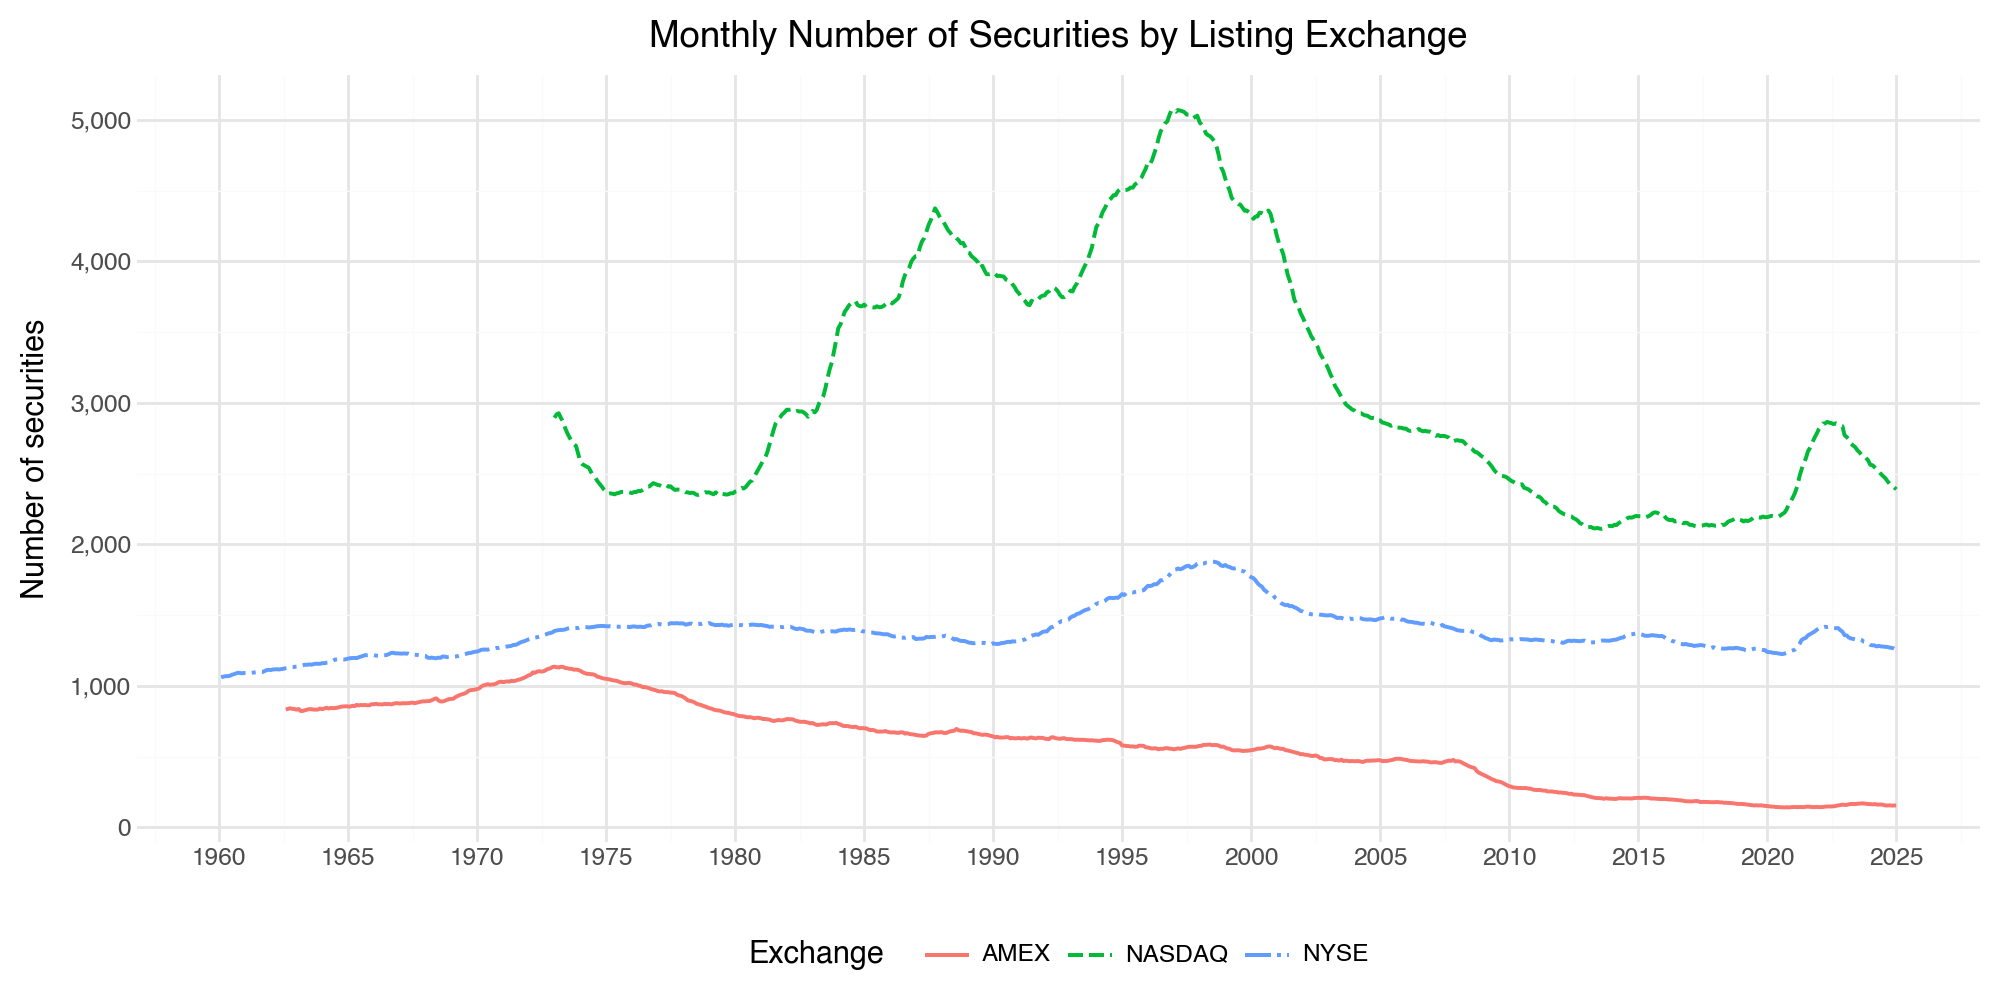

In [556]:
import pandas as pd

from plotnine import (
    ggplot, aes, geom_line, labs,
    scale_x_datetime, scale_y_continuous,
    theme_minimal, theme
)
from mizani.labels import label_comma

# Make sure date is in datetime format
crsp["date"] = pd.to_datetime(crsp["date"])

# Count the number of securities by exchange and month
securities_per_exchange = (
    crsp
    .dropna(subset=["exchange", "date"])
    .groupby(["exchange", "date"], as_index=False)
    .size()
    .rename(columns={"size": "n"})
    .sort_values(["exchange", "date"])
)

# Plot monthly number of securities by listing exchange
securities_per_exchange_figure = (
    ggplot(
        securities_per_exchange,
        aes(x="date", y="n", color="exchange", linetype="exchange")
    )
    + geom_line(size=0.8)
    + labs(
        x="",
        y="Number of securities",
        color="Exchange",
        linetype="Exchange",
        title="Monthly Number of Securities by Listing Exchange",
    )
    + scale_x_datetime(date_breaks="5 years", date_labels="%Y")
    + scale_y_continuous(labels=label_comma())
    + theme_minimal()
    + theme(
        legend_position="bottom",
        figure_size=(10, 5),
    )
)

securities_per_exchange_figure.show()

In [557]:
# transform industry codes to industry descriptions

def assign_industry(siccd):
    if 1 <= siccd <= 999:
        return "Agriculture"
    elif 1000 <= siccd <= 1499:
        return "Mining"
    elif 1500 <= siccd <= 1799:
        return "Construction"
    elif 2000 <= siccd <= 3999:
        return "Manufacturing"
    elif 4000 <= siccd <= 4899:
        return "Transportation"
    elif 4900 <= siccd <= 4999:
        return "Utilities"
    elif 5000 <= siccd <= 5199:
        return "Wholesale"
    elif 5200 <= siccd <= 5999:
        return "Retail"
    elif 6000 <= siccd <= 6799:
        return "Finance"
    elif 7000 <= siccd <= 8999:
        return "Services"
    elif 9000 <= siccd <= 9999:
        return "Public"
    else:
        return "Missing"

crsp["industry"] = (crsp["siccd"].apply(assign_industry))

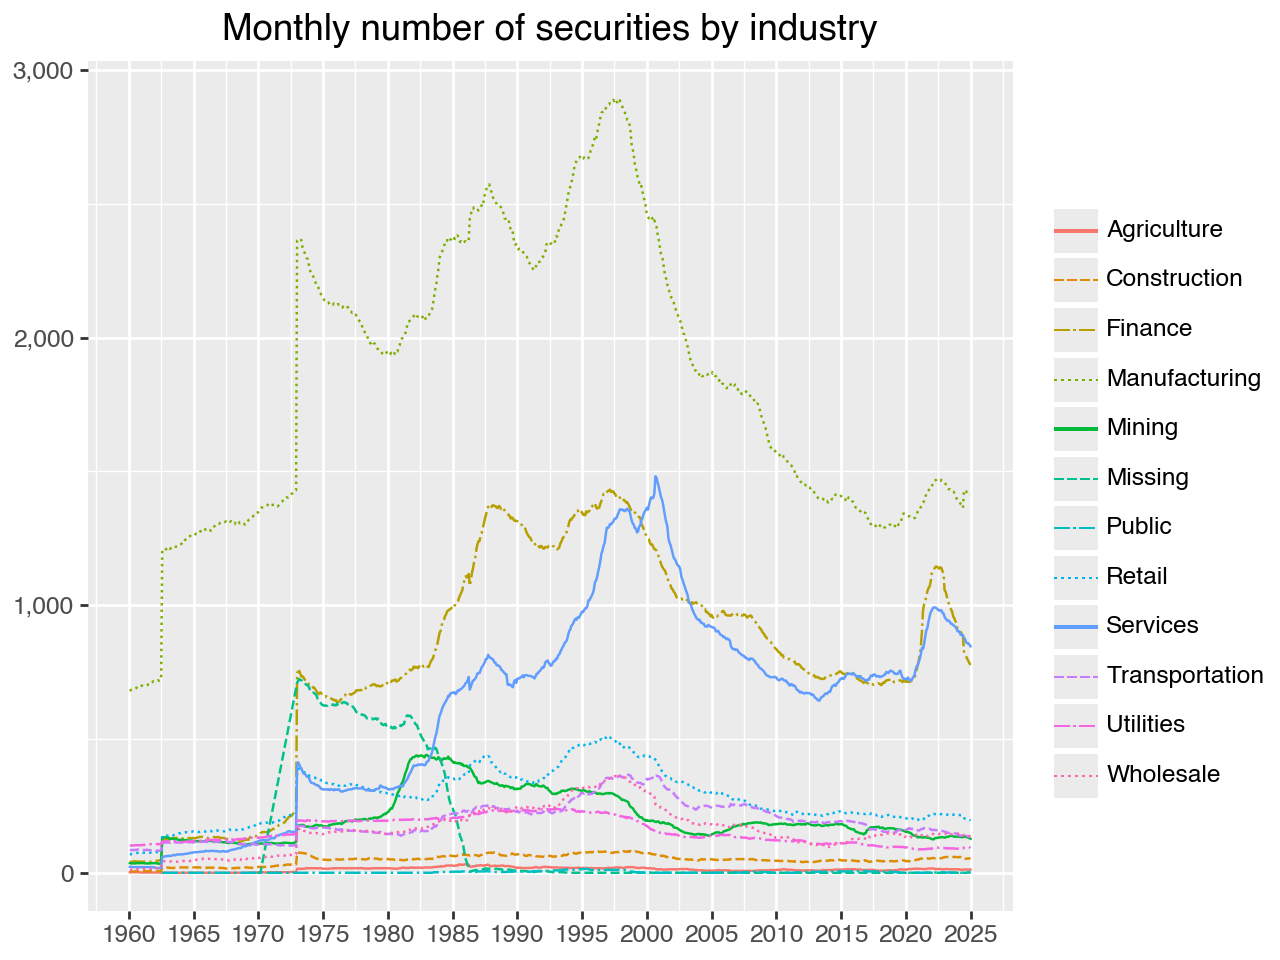

In [558]:
from plotnine import (
    ggplot, aes, geom_line, labs,
    scale_x_datetime, scale_y_continuous,
    scale_linetype_manual,
    theme_minimal, theme
)
from mizani.labels import label_comma

securities_per_industry = (crsp
    .groupby(["industry", "date"])
    .size()
    .reset_index(name="n")
)

linetypes = ["-", "--", "-.", ":"]
n_industries = securities_per_industry["industry"].nunique()

securities_per_industry_figure = (
    ggplot(
        securities_per_industry, 
        aes(x="date", y="n", color="industry", linetype="industry")
    )
    + geom_line()
    + labs(
        x="", y="", color="", linetype="",
        title="Monthly number of securities by industry"
        )
    + scale_x_datetime(date_breaks="5 years", date_labels="%Y")
    + scale_y_continuous(labels=comma_format())
    + scale_linetype_manual(
        values=[linetypes[l % len(linetypes)] for l in range(n_industries)]
        ) 
)
securities_per_industry_figure.show()

In [559]:
import pandas as pd

# Convert shares outstanding from thousands of shares to actual shares
crsp["shrout"] = pd.to_numeric(crsp["shrout"], errors="coerce") * 1000

# create market capitalization
# use millions of USD in the calculation
# sometimes, CSRP shows a negative price, which means bid-ask average
import numpy as np
crsp["me"] = crsp["shrout"] * crsp["prc"].abs() / 1000000
crsp = crsp.drop(['prc','shrout'], axis=1)

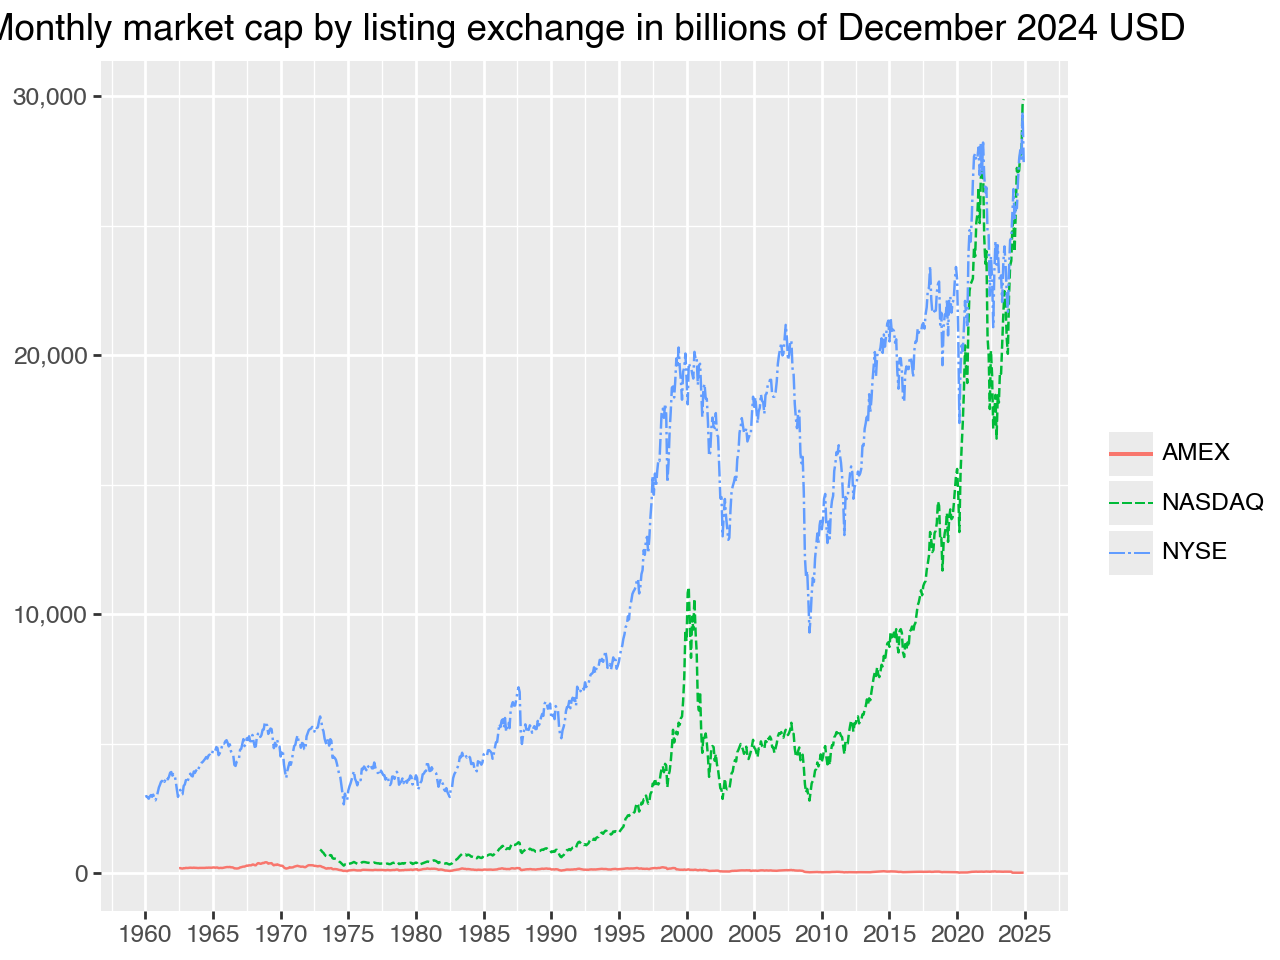

In [560]:
import pandas as pd

from plotnine import (
    ggplot, aes, geom_line, labs,
    scale_x_datetime, scale_y_continuous
)
from mizani.labels import label_comma

# Download monthly CPI from FRED
series = "CPIAUCNS"
url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series}"

cpi = (
    pd.read_csv(url)
    .assign(
        date=lambda x: pd.to_datetime(x["observation_date"]),
        cpi_value=lambda x: pd.to_numeric(x[series], errors="coerce")
    )
    .get(["date", "cpi_value"])
    .dropna()
)

base_month = pd.Timestamp("2024-12-01")
base_month_label = "December 2024"

# Keep CPI observations up to Dec 2024
cpi = cpi[cpi["date"] <= base_month].copy()

# Normalize CPI so that Dec 2024 equals 1
base_cpi = cpi.loc[cpi["date"] == base_month, "cpi_value"].iloc[0]
cpi["cpi"] = cpi["cpi_value"] / base_cpi

# Make sure CRSP date is monthly date compatible with FRED
crsp["date"] = pd.to_datetime(crsp["date"]).dt.to_period("M").dt.to_timestamp()

market_cap_per_exchange = (
    crsp
    .merge(cpi[["date", "cpi"]], how="left", on="date")
    .groupby(["date", "exchange"], as_index=False)
    .agg(me=("me", "sum"), cpi=("cpi", "mean"))
    .assign(me=lambda x: x["me"] / x["cpi"])
)

market_cap_per_exchange_figure = (
    ggplot(
        market_cap_per_exchange,
        aes(x="date", y="me / 1000", color="exchange", linetype="exchange")
    )
    + geom_line()
    + labs(
        x="",
        y="",
        color="",
        linetype="",
        title=f"Monthly market cap by listing exchange in billions of {base_month_label} USD"
    )
    + scale_x_datetime(date_breaks="5 years", date_labels="%Y")
    + scale_y_continuous(labels=label_comma())
)

market_cap_per_exchange_figure.show()

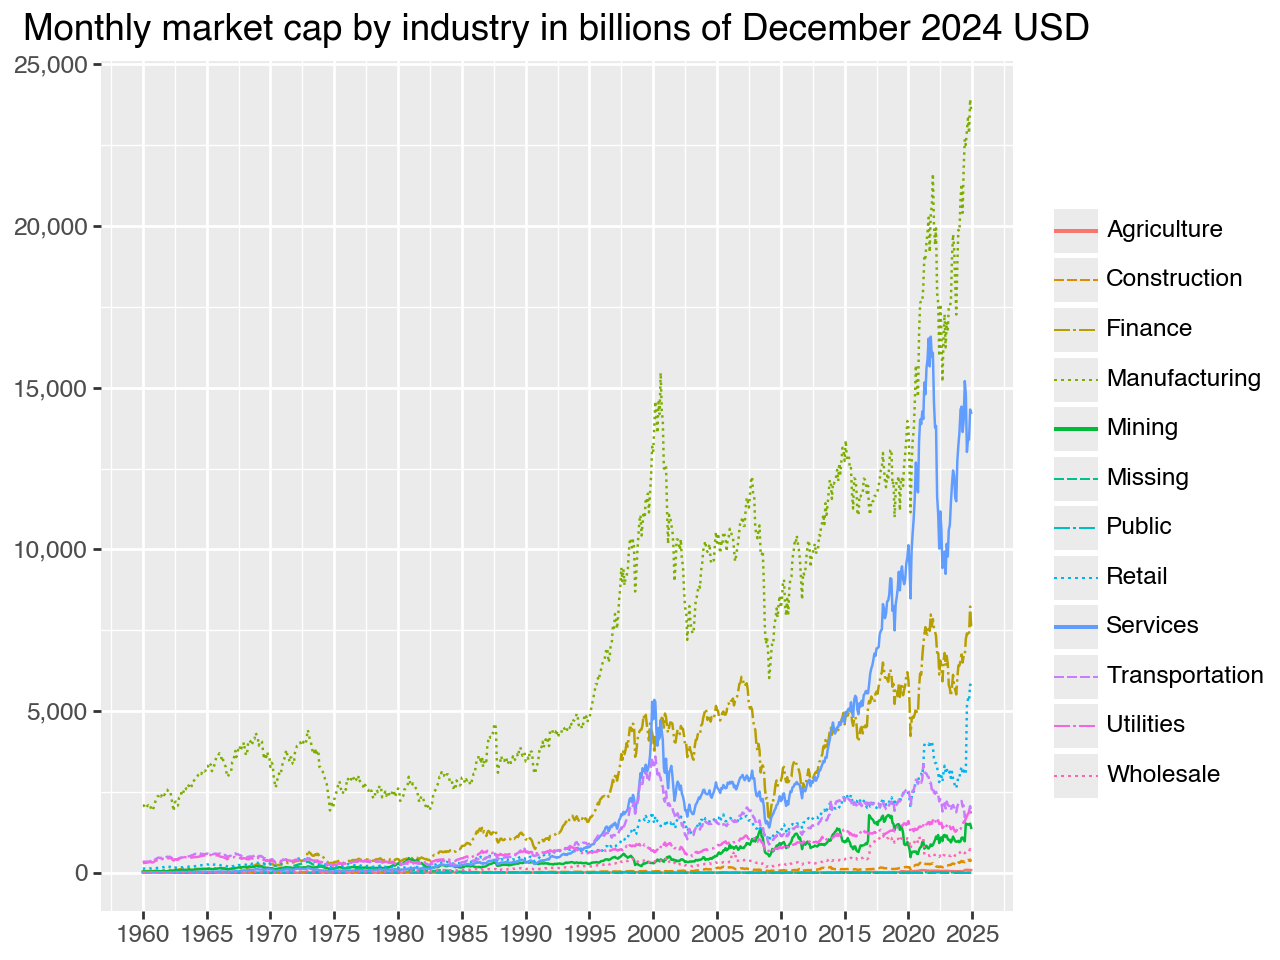

In [561]:
from plotnine import (
    ggplot, aes, geom_line, labs,
    scale_x_datetime, scale_y_continuous,
    scale_linetype_manual
)
from mizani.labels import label_comma

market_cap_per_industry = (
    crsp
    .merge(cpi[["date", "cpi"]], how="left", on="date")
    .dropna(subset=["cpi"])
    .groupby(["date", "industry"], as_index=False)
    .agg(me=("me", "sum"), cpi=("cpi", "mean"))
    .assign(me=lambda x: x["me"] / x["cpi"])
)

linetypes = ["-", "--", "-.", ":"]
industries = sorted(market_cap_per_industry["industry"].unique())
n_industries = len(industries)

market_cap_per_industry_figure = (
    ggplot(
        market_cap_per_industry,
        aes(x="date", y="me / 1000", color="industry", linetype="industry")
    )
    + geom_line()
    + labs(
        x="",
        y="",
        color="",
        linetype="",
        title=f"Monthly market cap by industry in billions of {base_month_label} USD"
    )
    + scale_x_datetime(date_breaks="5 years", date_labels="%Y")
    + scale_y_continuous(labels=label_comma())
    + scale_linetype_manual(
        values=[linetypes[i % len(linetypes)] for i in range(n_industries)]
    )
)

market_cap_per_industry_figure.show()

In [562]:
### Aggregate Market Cap ###

# One firm (permco) may have various securities (permno)
# A commno practice way is to replace the largest permno me with the total me
# For example, firm 500 (permco) has two stocks 10001 (permno) with 800 me and 10002 (permno) with 200 me
# 1. we first calculate total me equals to 800 + 200 = 1000
# 2. we find the largest me permno and save only this record which is 10001
# 3. we replace 10001 me 800 with the total me 1000
# 4. In the end, there are only one record: 500(permco) 10001(permno) 1000(me)

# sum of me across different permno belonging to same permco a given date
crsp_summe = crsp.groupby(['jdate','permco'])['me'].sum().reset_index()

# largest mktcap within a permco/date
crsp_maxme = crsp.groupby(['jdate','permco'])['me'].max().reset_index()

# join by jdate/maxme to find the permno
crsp1=pd.merge(crsp, crsp_maxme, how='inner', on=['jdate','permco','me'])

# drop me column and replace with the sum me
crsp1=crsp1.drop(['me'], axis=1)

# join with sum of me to get the correct market cap info
crsp2=pd.merge(crsp1, crsp_summe, how='inner', on=['jdate','permco'])

# sort by permno and date and also drop duplicates
crsp2=crsp2.sort_values(by=['permno','jdate']).drop_duplicates()

In [611]:
### Fama French use last year December me to calculate BE/ME
### take July_t to June_t+1 as fiscal year t to avoid look ahead bais
### for example, 1986-02-28 is fiscal year 1985, but 2024-08-30 is fiscal year 2024

# keep December market cap
crsp2['year']=crsp2['jdate'].dt.year
crsp2['month']=crsp2['jdate'].dt.month
decme=crsp2[crsp2['month']==12]
decme=decme[['permno','date','jdate','me','year']].rename(columns={'me':'dec_me'})

# July to June dates
crsp2['ffdate']=crsp2['jdate']+MonthEnd(-6)
crsp2['ffyear']=crsp2['ffdate'].dt.year
crsp2['ffmonth']=crsp2['ffdate'].dt.month
crsp2['1+retx']=1+crsp2['retx']
crsp2=crsp2.sort_values(by=['permno','date'])

In [612]:
print(crsp2[crsp2["permno"] == 10026])

      permno  permco       date       ret      retx primaryexch  siccd  \
2744   10026    7976 1986-02-01   0.06383   0.06383           Q   2050   
2745   10026    7976 1986-03-01  0.133333  0.133333           Q   2050   
2746   10026    7976 1986-04-01  0.070588  0.070588           Q   2050   
2747   10026    7976 1986-05-01  0.406593  0.406593           Q   2050   
2748   10026    7976 1986-06-01  -0.15625  -0.15625           Q   2050   
...      ...     ...        ...       ...       ...         ...    ...   
3501   10026    7976 2024-08-01  0.008832  0.008832           Q   2052   
3502   10026    7976 2024-09-01  0.016017   0.01134           Q   2052   
3503   10026    7976 2024-10-01 -0.046479 -0.046479           Q   2052   
3504   10026    7976 2024-11-01   0.05892   0.05892           Q   2052   
3505   10026    7976 2024-12-01 -0.103153 -0.107371           Q   2052   

          jdate exchange       industry  ...  year  month     ffdate ffyear  \
2744 1986-02-28   NASDAQ  Manufa

In [615]:
# cumret by stock
# cumretx_t = (1 + retx_1) × (1 + retx_2) × ... × (1 + retx_t)
crsp2['cumretx']=crsp2.groupby(['permno','ffyear'])['1+retx'].cumprod()

# lag cumret
crsp2['lcumretx']=crsp2.groupby(['permno'])['cumretx'].shift(1)

# lag market cap
crsp2['lme']=crsp2.groupby(['permno'])['me'].shift(1)

# if first permno then use me/(1+retx) to replace the missing value
crsp2['count']=crsp2.groupby(['permno']).cumcount()
crsp2['lme']=np.where(crsp2['count']==0, crsp2['me']/crsp2['1+retx'], crsp2['lme'])

# baseline me
# take ffmonth which is July as base me
mebase=crsp2[crsp2['ffmonth']==1][['permno','ffyear', 'lme']].rename(columns={'lme':'mebase'})

# merge result back together
# July, use June as baseme
# other months, use June * lcumretx
crsp3=pd.merge(crsp2, mebase, how='left', on=['permno','ffyear'])
crsp3['wt']=np.where(crsp3['ffmonth']==1, crsp3['lme'], crsp3['mebase']*crsp3['lcumretx'])

decme['year'] = decme['year'] + 1
decme=decme[['permno','year','dec_me']]

In [617]:
### take 10026 as an example
# date 2020-07-31, ffyear 2020, ffmonth 1, wt = lme 2401.23144
# date 2020-08-31, ffyear 2020, ffmonth 2, wt = June me * lcumretx
#                                             = June me * (1+retx_1)
#                                             = 2401.23144 * (1+ -0.031464)
# date 2020-09-31, ffyear 2020, ffmonth 3, wt = June me * lcumretx
#                                             = June me * (1 + retx_ffmonth1)(1 + retx_ffmonth2)
#                                             = 2401.23144 * (1 + -0.031464)(1 + 0.104118)

print(
    crsp3[
        (crsp3["permno"] == 10026)
        & (crsp3["date"].between("2019-12-31", "2020-12-31"))
    ]
)

      permno  permco       date       ret      retx primaryexch  siccd  \
3780   10026    7976 2020-01-01 -0.100016 -0.100016           Q   2052   
3781   10026    7976 2020-02-01  -0.03027  -0.03027           Q   2052   
3782   10026    7976 2020-03-01 -0.243679 -0.247606           Q   2052   
3783   10026    7976 2020-04-01  0.049835  0.049835           Q   2052   
3784   10026    7976 2020-05-01  0.012595  0.012595           Q   2052   
3785   10026    7976 2020-06-01 -0.007178 -0.011661           Q   2052   
3786   10026    7976 2020-07-01 -0.031464 -0.031464           Q   2052   
3787   10026    7976 2020-08-01  0.104118  0.104118           Q   2052   
3788   10026    7976 2020-09-01 -0.036668 -0.040897           Q   2052   
3789   10026    7976 2020-10-01  0.039727  0.039727           Q   2052   
3790   10026    7976 2020-11-01  0.072435  0.072435           Q   2052   
3791   10026    7976 2020-12-01  0.072616  0.068643           Q   2052   

          jdate exchange       indust

In [619]:
### date 2020-09-31, ffyear 2020, ffmonth 3
print(2401.23144 * (1 -0.031464)*(1 + 0.104118))

2567.824149878


In [621]:
# Info as of June
# use June info to calculate size, use last year dec to calculate beme

crsp3_jun = crsp3[crsp3['month']==6]

crsp_jun = pd.merge(crsp3_jun, decme, how='inner', on=['permno','year'])
crsp_jun=crsp_jun[['permno','date', 'jdate','me','wt','cumretx','mebase','lme','dec_me', 'primaryexch']]
crsp_jun=crsp_jun.sort_values(by=['permno','jdate']).drop_duplicates()

In [623]:
### take 10026 as an example
# date 2020-06-30, ffyear 2019, ffmonth 12, size use 2020-06-30(date) me 2401.23144, beme use 2019-12-31(jdate) me 3482.703

print(crsp_jun[crsp_jun["permno"] == 10026])

     permno       date      jdate          me           wt   cumretx  \
258   10026 1987-06-01 1987-06-30    47.78225    41.216699  0.909721   
259   10026 1988-06-01 1988-06-30    61.52125    45.958604  1.206109   
260   10026 1989-06-01 1989-06-30   123.55175    87.220108  1.506331   
261   10026 1990-06-01 1990-06-30    68.76375    71.639191  0.554622   
262   10026 1991-06-01 1991-06-30     151.107   110.438849  1.727275   
263   10026 1992-06-01 1992-06-30     100.681   119.295168  0.666667   
264   10026 1993-06-01 1993-06-30  170.755375   156.320541  1.750001   
265   10026 1994-06-01 1994-06-30   126.47725   128.387480  0.759398   
266   10026 1995-06-01 1995-06-30  118.157375   121.468162  0.999999   
267   10026 1996-06-01 1996-06-30    101.5335   122.836843   0.91089   
268   10026 1997-06-01 1997-06-30  135.253875   125.813356  1.336957   
269   10026 1998-06-01 1998-06-30     188.209   169.891943  1.357722   
270   10026 1999-06-01 1999-06-30     215.352   187.082052  1.14

# Section 4 Merging CRSP with Compustat

CRSP and Compustat use different keys to identify stocks and firms. CRSP uses permno for stocks, while Compustat uses gvkey to identify firms. Fortunately, a curated matching table on WRDS allows us to merge CRSP and Compustat, so we create a connection to the CRSP-Compustat Merged table (provided by CRSP).

In [627]:
#######################
# CCM Block           #
#######################

from pandas.tseries.offsets import YearEnd, MonthEnd

ccm = db.raw_sql("""
    select gvkey, lpermno as permno, linktype, linkprim,
           linkdt, linkenddt
    from crsp.ccmxpf_lnkhist
    where linktype in ('LC', 'LU')
      and linkprim in ('C', 'P')
""", date_cols=["linkdt", "linkenddt"])

# if linkenddt is missing then set to today date
ccm['linkenddt']=ccm['linkenddt'].fillna(pd.to_datetime('today'))

ccm1=pd.merge(comp[['gvkey','datadate','be', 'count']],ccm,how='left',on=['gvkey'])
ccm1['yearend']=ccm1['datadate']+YearEnd(0)
ccm1['jdate']=ccm1['yearend']+MonthEnd(6)

In [628]:
# set link date bounds
ccm2=ccm1[(ccm1['jdate']>=ccm1['linkdt'])&(ccm1['jdate']<=ccm1['linkenddt'])]
ccm2=ccm2[['gvkey','permno','datadate','yearend', 'jdate','be', 'count']]

# link comp and crsp
ccm_jun=pd.merge(crsp_jun, ccm2, how='inner', on=['permno', 'jdate'])
ccm_jun['beme']=ccm_jun['be']*1000/ccm_jun['dec_me']

In [629]:
print(ccm_jun)

        permno       date      jdate           me             wt   cumretx  \
0        10001 1987-06-01 1987-06-30     5.822125       5.602187  0.959184   
1        10001 1988-06-01 1988-06-30          6.2       6.379556  1.063829   
2        10001 1989-06-01 1989-06-30        7.007       6.944000      1.12   
3        10001 1990-06-01 1990-06-30     10.05225       9.759755  1.392858   
4        10001 1991-06-01 1991-06-30      11.2665      10.181126  1.076923   
...        ...        ...        ...          ...            ...       ...   
253677   93436 2020-06-01 2020-06-30    200844.66  149563.772562  4.832239   
253678   93436 2021-06-01 2021-06-30  668826.8391  581454.977907  3.147314   
253679   93436 2022-06-01 2022-06-30    701030.22  746130.101224   0.99076   
253680   93436 2023-06-01 2023-06-30    830857.98  636873.835161  1.166153   
253681   93436 2024-06-01 2024-06-30  632155.3632  565226.462817  0.755932   

               mebase            lme         dec_me primaryexch

In [630]:
# select NYSE stocks for bucket breakdown
# exchcd = 1 and positive beme and positive me and at least 2 years in comp
nyse=ccm_jun[(ccm_jun['primaryexch']=='N') & (ccm_jun['beme']>0) & (ccm_jun['me']>0) & \
             (ccm_jun['count']>=1)]

# size breakdown
nyse_sz=nyse.groupby(['jdate'])['me'].median().to_frame().reset_index().rename(columns={'me':'sizemedn'})

# beme breakdown
nyse_bm=nyse.groupby(['jdate'])['beme'].describe(percentiles=[0.3, 0.7]).reset_index()
nyse_bm=nyse_bm[['jdate','30%','70%']].rename(columns={'30%':'bm30', '70%':'bm70'})

nyse_breaks = pd.merge(nyse_sz, nyse_bm, how='inner', on=['jdate'])

# join back size and beme breakdown
ccm1_jun = pd.merge(ccm_jun, nyse_breaks, how='left', on=['jdate'])

In [635]:
def sz_bucket(row):
    if pd.isna(row["me"]) or pd.isna(row["sizemedn"]):
        return ""
    elif row["me"] <= row["sizemedn"]:
        return "S"
    else:
        return "B"


def bm_bucket(row):
    if pd.isna(row["beme"]) or pd.isna(row["bm30"]) or pd.isna(row["bm70"]):
        return ""
    elif 0 <= row["beme"] <= row["bm30"]:
        return "L"
    elif row["beme"] <= row["bm70"]:
        return "M"
    elif row["beme"] > row["bm70"]:
        return "H"
    else:
        return ""

In [637]:
print(ccm1_jun)

        permno       date      jdate           me             wt   cumretx  \
0        10001 1987-06-01 1987-06-30     5.822125       5.602187  0.959184   
1        10001 1988-06-01 1988-06-30          6.2       6.379556  1.063829   
2        10001 1989-06-01 1989-06-30        7.007       6.944000      1.12   
3        10001 1990-06-01 1990-06-30     10.05225       9.759755  1.392858   
4        10001 1991-06-01 1991-06-30      11.2665      10.181126  1.076923   
...        ...        ...        ...          ...            ...       ...   
253677   93436 2020-06-01 2020-06-30    200844.66  149563.772562  4.832239   
253678   93436 2021-06-01 2021-06-30  668826.8391  581454.977907  3.147314   
253679   93436 2022-06-01 2022-06-30    701030.22  746130.101224   0.99076   
253680   93436 2023-06-01 2023-06-30    830857.98  636873.835161  1.166153   
253681   93436 2024-06-01 2024-06-30  632155.3632  565226.462817  0.755932   

               mebase            lme         dec_me primaryexch

In [639]:
# Make sure sorting variables are numeric
ccm1_jun["beme"] = pd.to_numeric(ccm1_jun["beme"], errors="coerce")
ccm1_jun["me"] = pd.to_numeric(ccm1_jun["me"], errors="coerce")
ccm1_jun["count"] = pd.to_numeric(ccm1_jun["count"], errors="coerce")

# Valid observations for portfolio assignment
valid_port = (
    (ccm1_jun["beme"] > 0)
    & (ccm1_jun["me"] > 0)
    & (ccm1_jun["count"] >= 1)
).fillna(False)

# assign size portfolio
ccm1_jun["szport"] = ""
ccm1_jun.loc[valid_port, "szport"] = ccm1_jun.loc[valid_port].apply(
    sz_bucket,
    axis=1
)

# assign book-to-market portfolio
ccm1_jun["bmport"] = ""
ccm1_jun.loc[valid_port, "bmport"] = ccm1_jun.loc[valid_port].apply(
    bm_bucket,
    axis=1
)

# create positive book-to-market and non-missing portfolio indicators
ccm1_jun["posbm"] = valid_port.astype(int)
ccm1_jun["nonmissport"] = (ccm1_jun["bmport"] != "").astype(int)

In [640]:
# store portfolio assignment as of June
june=ccm1_jun[['permno','date', 'jdate', 'bmport','szport','posbm','nonmissport']]
june['ffyear']=june['jdate'].dt.year

# merge back with monthly records
crsp3 = crsp3[['date','permno','me','wt','cumretx','ffyear','jdate','ret']]
ccm3=pd.merge(crsp3, 
        june[['permno','ffyear','szport','bmport','posbm','nonmissport']], how='left', on=['permno','ffyear'])

# keeping only records that meet the criteria
ccm4=ccm3[(ccm3['wt']>0)& (ccm3['posbm']==1) & (ccm3['nonmissport']==1)]

/var/folders/js/v4b7674569xb00v24gf98wrh0000gn/T/ipykernel_24364/2225375088.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


# Section 5 Fama French Factors

In [642]:
############################
# Form Fama French Factors #
############################

# function to calculate value weighted return
def wavg(group, avg_name, weight_name):
    d = group[avg_name]
    w = group[weight_name]
    try:
        return (d * w).sum() / w.sum()
    except ZeroDivisionError:
        return np.nan

In [643]:
# value-weigthed return
vwret=ccm4.groupby(['jdate','szport','bmport']).apply(wavg, 'ret','wt').to_frame().reset_index().rename(columns={0: 'vwret'})
vwret['sbport']=vwret['szport']+vwret['bmport']

# firm count
vwret_n=ccm4.groupby(['jdate','szport','bmport'])['ret'].count().reset_index().rename(columns={'ret':'n_firms'})
vwret_n['sbport']=vwret_n['szport']+vwret_n['bmport']

# tranpose
ff_factors=vwret.pivot(index='jdate', columns='sbport', values='vwret').reset_index()
ff_nfirms=vwret_n.pivot(index='jdate', columns='sbport', values='n_firms').reset_index()

/var/folders/js/v4b7674569xb00v24gf98wrh0000gn/T/ipykernel_24364/3212440357.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


In [644]:
# create SMB and HML factors
ff_factors['WH']=(ff_factors['BH']+ff_factors['SH'])/2
ff_factors['WL']=(ff_factors['BL']+ff_factors['SL'])/2
ff_factors['WHML'] = ff_factors['WH']-ff_factors['WL']

ff_factors['WB']=(ff_factors['BL']+ff_factors['BM']+ff_factors['BH'])/3
ff_factors['WS']=(ff_factors['SL']+ff_factors['SM']+ff_factors['SH'])/3
ff_factors['WSMB'] = ff_factors['WS']-ff_factors['WB']
ff_factors=ff_factors.rename(columns={'jdate':'date'})

# n firm count
ff_nfirms['H']=ff_nfirms['SH']+ff_nfirms['BH']
ff_nfirms['L']=ff_nfirms['SL']+ff_nfirms['BL']
ff_nfirms['HML']=ff_nfirms['H']+ff_nfirms['L']

ff_nfirms['B']=ff_nfirms['BL']+ff_nfirms['BM']+ff_nfirms['BH']
ff_nfirms['S']=ff_nfirms['SL']+ff_nfirms['SM']+ff_nfirms['SH']
ff_nfirms['SMB']=ff_nfirms['B']+ff_nfirms['S']
ff_nfirms['TOTAL']=ff_nfirms['SMB']
ff_nfirms=ff_nfirms.rename(columns={'jdate':'date'})

In [645]:
from pandas.tseries.offsets import MonthEnd
from scipy import stats
import pandas as pd

###################
# Compare With FF #
###################

_ff = db.get_table(library="ff", table="factors_monthly")
_ff = _ff[["date", "smb", "hml"]].copy()

_ff["date"] = pd.to_datetime(_ff["date"]) + MonthEnd(0)

ff_factors["date"] = pd.to_datetime(ff_factors["date"]) + MonthEnd(0)

_ffcomp = pd.merge(
    _ff,
    ff_factors[["date", "WSMB", "WHML"]],
    how="inner",
    on="date"
)

_ffcomp70 = _ffcomp[_ffcomp["date"] >= pd.Timestamp("1970-01-01")]

print(stats.pearsonr(_ffcomp70["smb"], _ffcomp70["WSMB"]))
print(stats.pearsonr(_ffcomp70["hml"], _ffcomp70["WHML"]))

PearsonRResult(statistic=0.9960263934585891, pvalue=0.0)
PearsonRResult(statistic=0.9843642982108708, pvalue=0.0)


In [647]:
_ffcomp.head(2)

,date,smb,hml,WSMB,WHML
0,1962-07-31,0.0152,-0.0337,0.011757,-0.048484
1,1962-08-31,0.0122,-0.0112,0.009425,-0.014150


In [648]:
_ffcomp.dtypes

date    datetime64[ns]
smb            Float64
hml            Float64
WSMB           float64
WHML           float64
dtype: object

In [651]:
_ffcomp.tail()

,date,smb,hml,WSMB,WHML
745,2024-08-31,-0.035,-0.011,-0.037297,-0.005798
746,2024-09-30,-0.0012,-0.0277,-0.004307,-0.019387
747,2024-10-31,-0.0096,0.0089,-0.007554,0.005524
748,2024-11-30,0.0454,0.0029,0.052749,-0.009844
749,2024-12-31,-0.027,-0.0298,-0.025422,-0.031355


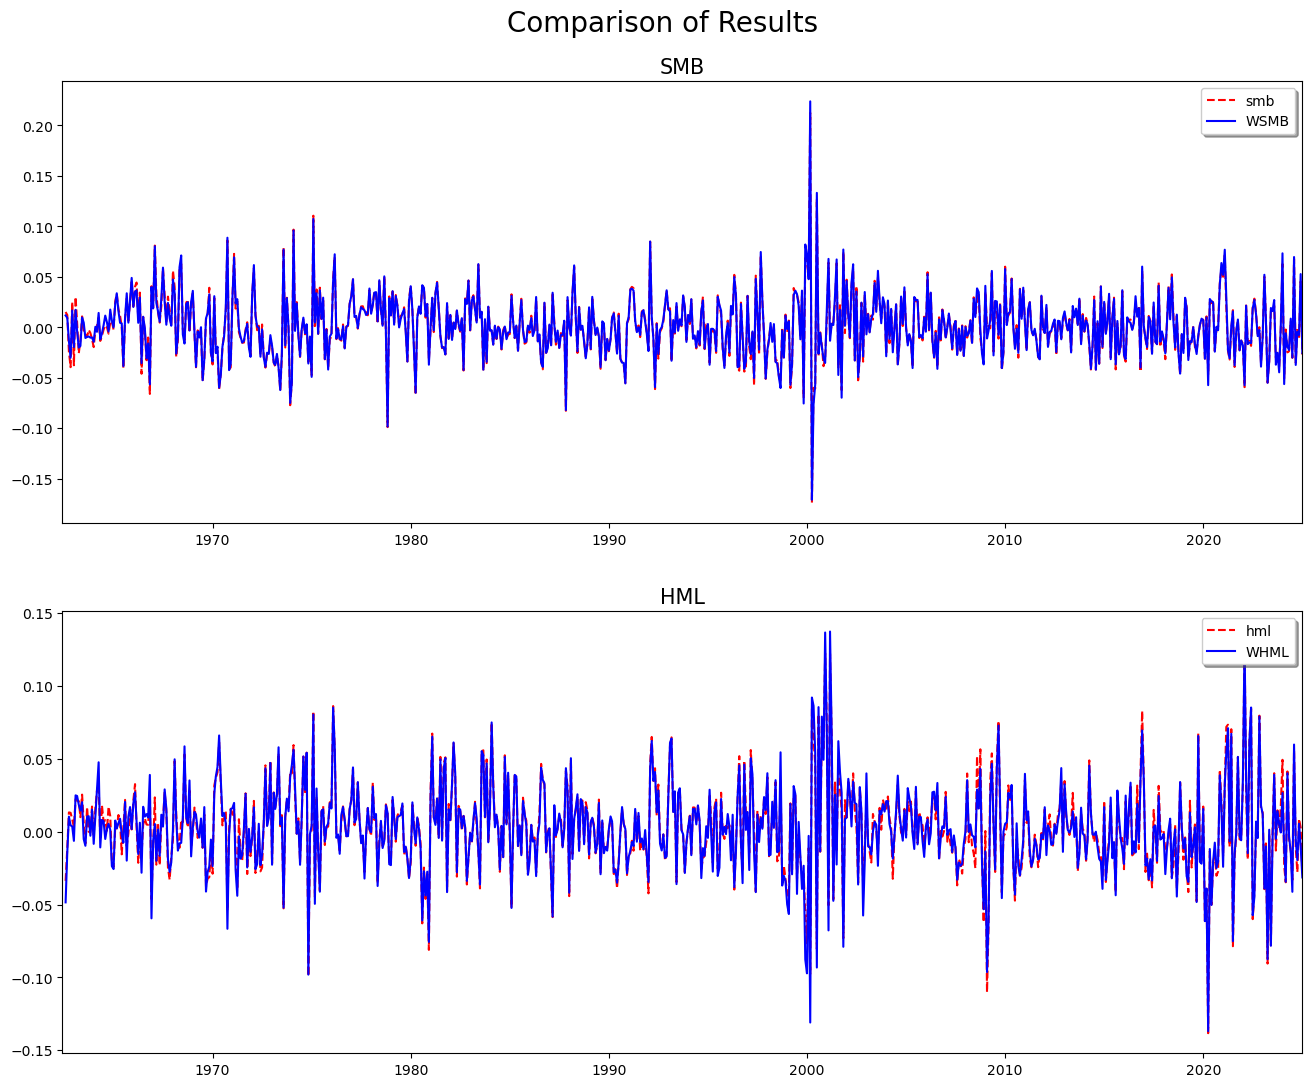

In [652]:
import matplotlib.pyplot as plt
import datetime as dt

_ffcomp = _ffcomp.sort_values("date")

plt.figure(figsize=(16, 12))
plt.suptitle("Comparison of Results", fontsize=20)

ax1 = plt.subplot(211)
ax1.set_title("SMB", fontsize=15)
ax1.set_xlim([dt.datetime(1962, 6, 1), dt.datetime(2024, 12, 31)])
ax1.plot(_ffcomp["date"], _ffcomp["smb"], "r--", label="smb")
ax1.plot(_ffcomp["date"], _ffcomp["WSMB"], "b-", label="WSMB")
ax1.legend(loc="upper right", shadow=True)

ax2 = plt.subplot(212)
ax2.set_title("HML", fontsize=15)
ax2.set_xlim([dt.datetime(1962, 6, 1), dt.datetime(2024, 12, 31)])
ax2.plot(_ffcomp["date"], _ffcomp["hml"], "r--", label="hml")
ax2.plot(_ffcomp["date"], _ffcomp["WHML"], "b-", label="WHML")
ax2.legend(loc="upper right", shadow=True)

plt.subplots_adjust(top=0.92, hspace=0.2)
plt.show()